In [95]:
# Imports and RFSoC connection
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick import QickConfig
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import inspect
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "10.1.9.48"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())

print(soccfg)

QICK running on RFSoC4x2, software version 0.2.414

Firmware configuration (built Fri Jul  3 12:34:42 2026):

	Global clocks (MHz): tProc dispatcher timing 491.520, RF reference 491.520
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=7864.320 Msps, fabric=491.520 MHz
		envelope memory: 65536 complex samples (8.333 us)
		32-bit DDS, range=7864.320 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=7864.320 Msps, fabric=491.520 MHz
		envelope memory: 65536 complex samples (8.333 us)
		32-bit DDS, range=7864.320 MHz
		DAC tile 2, blk 0 is DAC_A

	3 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 2
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.2 (has edge counter, no weights)
		memory 16384 accumulated, 16384 decimated (29.630 us)
		triggered by tport 0, pin 0, feedback to tProc input

In [96]:
gen_ch = 0
ro_ch = 0

In [97]:
# dataset = np.load(base / "adc_recovered_1k_padded.npy")
# dataset *= 10
# target_peak = 25000  # roughly half of 32766, comfortable margin
# #scale_factor = target_peak / np.max(np.abs(dataset))  # compute once, globally
# #print(scale_factor)
# dataset = dataset * .8

In [98]:
# # --------------------
# # working for using two notebooks
# # ----------------------

# base = Path('.')
# #dataset = np.load(base / "adc_recovered_1k_padded.npy")
# dataset = np.load(base / "X_2_padded_11k.npy")
# dataset = dataset[:500]
# phi = np.load(base / "Phi.npy")
# y = np.load(base / "y_1k_truncated.npy")
# y=y[:250]
# #dataset = dataset[np.newaxis, :]
# global_scale = np.max(np.abs(dataset))
# print(global_scale)
# # dataset = dataset / global_scale
# print(np.max(np.abs(dataset)))
# dataset = dataset[:250]
# #dataset *= 8

# np.save(base / "y_loopback_1", y)

# shot_idx = 0
# dac_waveform = dataset[shot_idx]
# print(dataset.shape)

In [99]:
base = Path('.')
#dataset = np.load(base / "adc_recovered_1k_padded.npy")
dataset = np.load(base / "X_2_padded_11k.npy")
dataset = dataset[:500]
phi = np.load(base / "Phi.npy")
phi = phi[:500]
y = np.load(base / "y_1k_truncated.npy")
y=y[:500]
#dataset = dataset[np.newaxis, :]
global_scale = np.max(np.abs(dataset))
print(global_scale)
# dataset = dataset / global_scale
print(np.max(np.abs(dataset)))
dataset = dataset[:500]
dataset *= 8
#dataset *= 10

np.save(base / "y_loopback_1", y)

shot_idx = 0
dac_waveform = dataset[shot_idx]
print(dataset.shape)

3003.225646689353
3003.225646689353
(500, 22000)


In [100]:
def calculate_waveform_vals(shot):
    #waveform = np.asarray(shot, dtype=float).reshape(-1)
    I = shot[0::2]  # every even index
    Q = shot[1::2]  # every odd index
    I = np.asarray(I, dtype=float).reshape(-1)
    Q = np.asarray(Q, dtype=float).reshape(-1)
    #waveform = shot
    return {
    "waveform_I": I,
    "waveform_Q": Q,
    "gain": 1.0,
    "freq": 50,
    "phase": phi[shot_idx][0],#0,
    "length": 16,#1.393, #it dont matter
}

In [101]:
base_config = {
    "gen_ch": gen_ch,
    "ro_ch": ro_ch,
    "nqz": 1,

    "reps": 1,
    "soft_avgs": 100,#1,
    "final_delay": 100,

    "readout_length": 1.393,
    "adc_trig_offset": 0.31,#0.31,#0.44
    "length": 16,#1.393, #it dont matter

    # "gain": 1.0,
    "freq": 50,
    # "phase": 0,

    "mode": "oneshot",
    "stdysel": "zero",
    "outsel": "product",
}

(22000,)
-4303.481049566232
5979.338888738805


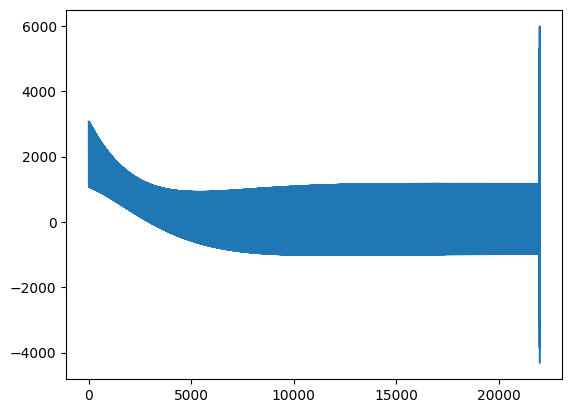

In [102]:
print(dac_waveform.shape)
print(dac_waveform.min())
print(dac_waveform.max())

plt.plot(dac_waveform)

In [103]:
shot_info = calculate_waveform_vals(dac_waveform)

def update_config(base_config, shot_info):
    config = base_config.copy()
    config.update(shot_info)
    return config

In [104]:
config = base_config.copy()
config.update(shot_info)

In [105]:
class LoopbackProgram(AveragerProgramV2):

    def __init__(self, soccfg, cfg):
        super().__init__(
            soccfg,
            reps=cfg["reps"],
            final_delay=cfg["final_delay"],
            cfg=cfg,
        )

    def _initialize(self, cfg):
        self.declare_gen(
            ch=cfg["gen_ch"],
            nqz=cfg["nqz"]
        )

        self.declare_readout(
            ch=cfg["ro_ch"],
            length=cfg["readout_length"]
        )

        # load arbitrary waveform into memory
        self.add_envelope(
            ch=cfg["gen_ch"],
            name="readout_env",
            # idata=cfg["waveform"],
            # qdata=np.zeros_like(cfg["waveform"])
            idata=cfg["waveform_I"],
            qdata=cfg["waveform_Q"]
        )

        # create pulse using envelope
        print("add_pulse phase arg:", cfg["phase"]) #---------------------- CHANGE BACK LATER
        self.add_pulse(
            ch=cfg["gen_ch"],
            name="readout_pulse",
            style="arb",#"const",#"arb",
            #length=cfg["length"],
            envelope="readout_env",
            gain=cfg["gain"],
            freq=cfg["freq"],
            phase=cfg["phase"], #CHANGE BACK IF BROKEN -------------------- to 0
            outsel=cfg["outsel"],#cfg["outsel"],
            mode=cfg["mode"],
            stdysel=cfg["stdysel"],
            ro_ch=cfg["ro_ch"]
        )
        print("outsel:", config["outsel"]) #-------------------CHANGE BACK LATER
        # configure the readout block used by the acquisition loop
        self.add_readoutconfig(
            ch=cfg["ro_ch"],
            name="ro_cfg",
            freq=cfg["freq"],
            gen_ch=cfg["gen_ch"]
        )

    def _body(self, cfg):
        self.pulse(
            ch=cfg["gen_ch"],
            name="readout_pulse"
        )

        self.send_readoutconfig(
            ch=cfg["ro_ch"],
            name="ro_cfg",
            t=0
        )

        self.trigger(
            ros=[cfg["ro_ch"]],
            pins=[0],
            t=cfg["adc_trig_offset"],
            width=10
        )

In [106]:
# # ------------------
# # USE FOR TWO NOTEBOOKS
# # ------------------
# n = np.zeros(2)
# np.save("acquired_dataset.npy", n)
# print(dataset.shape)
# os.remove("acquired_dataset.npy")

In [107]:
import gc
def prepare_waveform(waveform):
    arr = np.asarray(waveform, dtype=float).reshape(-1)
    if arr.size == 0:
        return np.zeros(16, dtype=float)

    # QICK requires the envelope length to be an integer multiple of 16.
    if arr.size % 32 != 0: #was 16 before
        target_len = int(np.ceil(arr.size / 32) * 32) #was 16 before
        if arr.size < target_len:
            arr = np.pad(arr, (0, target_len - arr.size), mode='constant')
        else:
            arr = arr[:target_len]

    return arr

max_rows = dataset.shape[0]
max_rows = 500
acquired_rows = []

for idx in range(max_rows):
    waveform = prepare_waveform(dataset[idx])
    print(waveform.shape, np.max(np.abs(waveform))) 
    shot_info = calculate_waveform_vals(waveform)
    config = base_config.copy()
    config.update(shot_info)
    config['waveform'] = waveform
    config['shot_idx'] = idx

    print(np.max(np.abs(dataset)))       # should be ~1.0 (or slightly under)
    print(np.max(np.abs(waveform)))      # per-shot, should be ≤ 1.0
    print("phase being sent:", config["phase"]) #NEW CHANGE---------------
    prog = LoopbackProgram(soccfg, config)
    iq = prog.acquire_decimated(soc)

    if isinstance(iq, list):
        record = np.concatenate([np.asarray(arr).reshape(-1) for arr in iq])
    else:
        record = np.asarray(iq).reshape(-1)

    acquired_rows.append(record)

    if idx % 1000 == 0 or idx == max_rows - 1:
        print(f'processed {idx + 1}/{max_rows} shots')

    del prog, iq, config, shot_info, waveform, record
    gc.collect()

acquired_data = np.vstack(acquired_rows)
np.save(base / 'acquired_dataset.npy', acquired_data)
print(f'saved {acquired_data.shape[0]} acquired rows to {base / "acquired_dataset.npy"}')

(22016,) 5979.338888738805
24025.805173514826
5979.338888738805
phase being sent: 0.07015111590622494
add_pulse phase arg: 0.07015111590622494
outsel: product


  0%|          | 0/1 [00:00<?, ?it/s]

processed 1/500 shots
(22016,) 5402.2192964706755
24025.805173514826
5402.2192964706755
phase being sent: 0.07015111590622494
add_pulse phase arg: 0.07015111590622494
outsel: product


  0%|          | 0/1 [00:00<?, ?it/s]

(22016,) 11281.112461992874
24025.805173514826
11281.112461992874
phase being sent: 0.07015111590622494
add_pulse phase arg: 0.07015111590622494
outsel: product


...

(22016,) 2937.96865639965
24025.805173514826
2937.96865639965
phase being sent: 0.07015111590622494
add_pulse phase arg: 0.07015111590622494
outsel: product


  0%|          | 0/1 [00:00<?, ?it/s]

(22016,) 8955.625187234968
24025.805173514826
8955.625187234968
phase being sent: 0.07015111590622494
add_pulse phase arg: 0.07015111590622494
outsel: product


  0%|          | 0/1 [00:00<?, ?it/s]

processed 500/500 shots
saved 500 acquired rows to acquired_dataset.npy


(500, 1540)


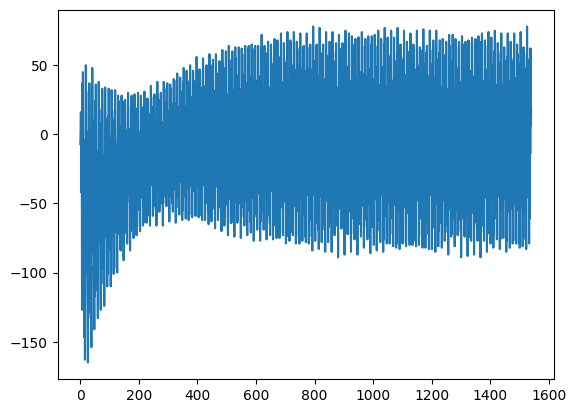

In [108]:
print(acquired_data.shape)
plt.plot(acquired_data[0])

In [109]:
print(acquired_data.shape)
print(acquired_data[0])
print(y[0])
print(y[1])
print(y.shape)

(500, 1540)
[-7.  2. 16. ... 62.  6. 18.]
1
0
(500,)


rows labeled 0: 246
rows labeled 1: 254


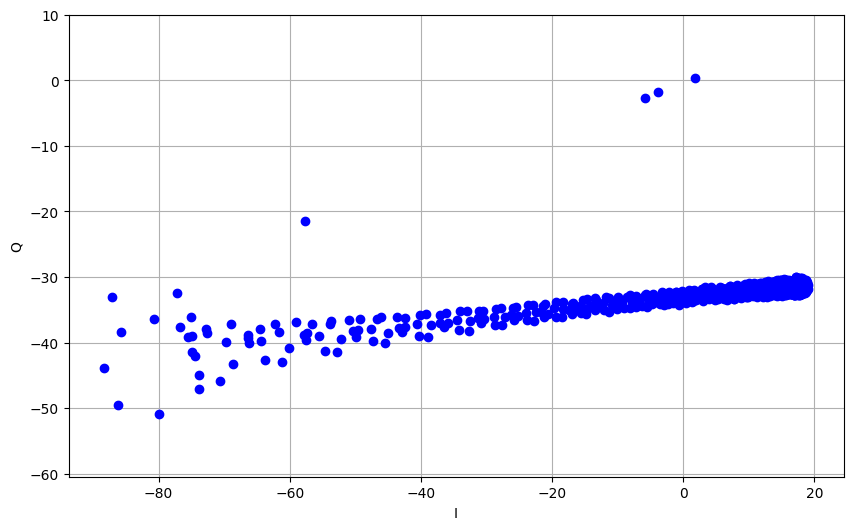

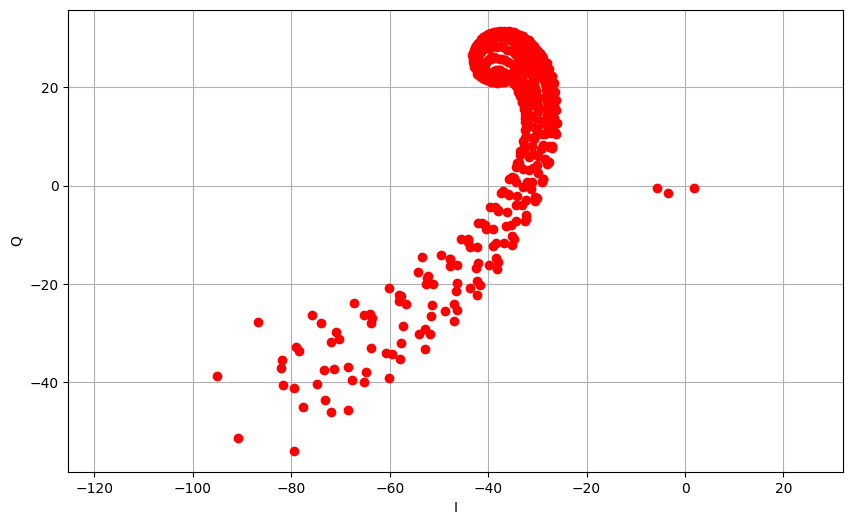

In [110]:
# Split the acquired rows into class-0 and class-1 groups using the matching y labels
acquired_data = np.asarray(acquired_data)
#y_labels = np.asarray(y).reshape(-1)

# if acquired_data.shape[0] != len(y_labels):
#     raise ValueError(f"acquired_data has {acquired_data.shape[0]} rows but y has {len(y_labels)} labels")

X_0 = acquired_data[y==0]#_labels == 0]
X_1 = acquired_data[y==1]#_labels == 1]

print("rows labeled 0:", X_0.shape[0])
print("rows labeled 1:", X_1.shape[0])

# Split interleaved I/Q pairs as [I0, Q0, I1, Q1, ...]
I_0 = X_0[:, 0::2]
Q_0 = X_0[:, 1::2]
I_1 = X_1[:, 0::2]
Q_1 = X_1[:, 1::2]

mean_I_0_axis = np.mean(I_0, axis=0)
mean_Q_0_axis = np.mean(Q_0, axis=0)
mean_I_1_axis = np.mean(I_1, axis=0)
mean_Q_1_axis = np.mean(Q_1, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

plt.figure(figsize=(10, 6))
plt.plot(mean_I_1_axis, mean_Q_1_axis, 'ro', label='Mean State 1')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

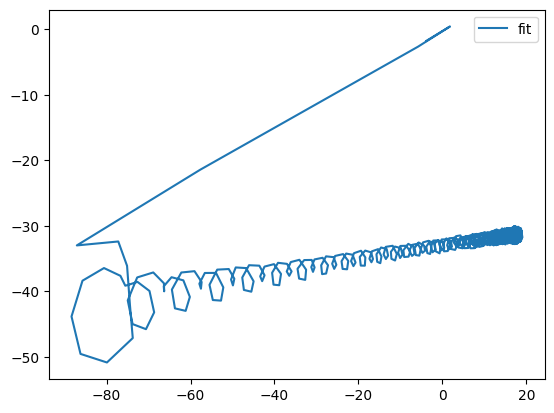

In [111]:
mean_fit0 = np.mean(X_0, axis=0)
mean_fit1 = np.mean(X_1, axis=0)

shots0 = X_0[:,0::2]+1j*X_0[:,1::2]

z0_fit = mean_fit0[0::2] + 1j*mean_fit0[1::2]
z1_fit = mean_fit1[0::2] + 1j*mean_fit1[1::2]

# noise0 = shots0-z0_fit

# print(np.mean(np.abs(noise0)))
# print(np.std(noise0.real))
# print(np.std(noise0.imag))

#plt.plot(z0_fit.real,z0_fit.imag,label="real")
plt.plot(z0_fit.real,z0_fit.imag,label="fit")
plt.legend()


In [ ]:
X_all_0 = np.load(base / '0528_X_all_0.npy')
X_all_1 = np.load(base / '0528_X_all_1.npy')

mean_real0 = np.mean(X_all_0, axis=0)
mean_real1 = np.mean(X_all_1, axis=0)

z_acq = np.concatenate([mean_fit0, mean_fit1])
z_real = np.concatenate([mean_real0, mean_real1])

A = np.vstack([z_acq, np.ones_like(z_acq)]).T
sol, *_ = np.linalg.lstsq(A, z_real, rcond=None)
a, b = sol

print("scale*rotation:", a, "offset:", b)

acquired_data_calibrated = a * acquired_data + b

scale*rotation: -3.6639980545463864 offset: 11.782055434252214


rows labeled 0: 246
rows labeled 1: 254


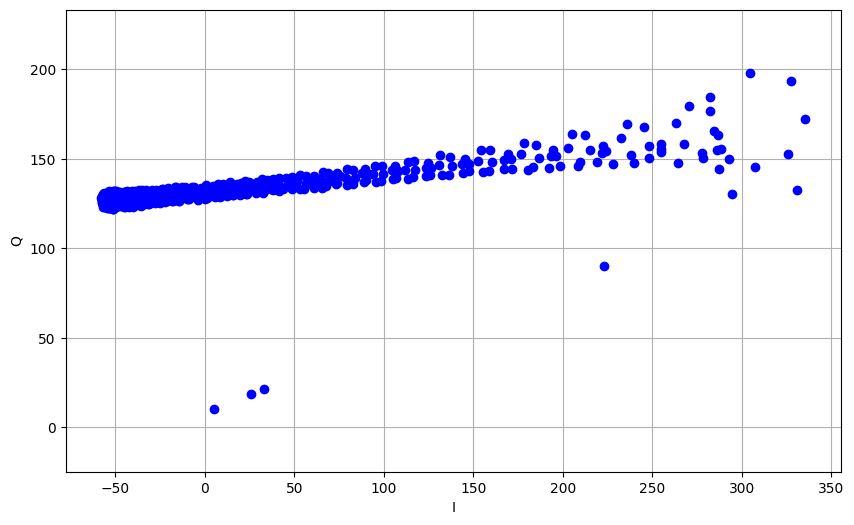

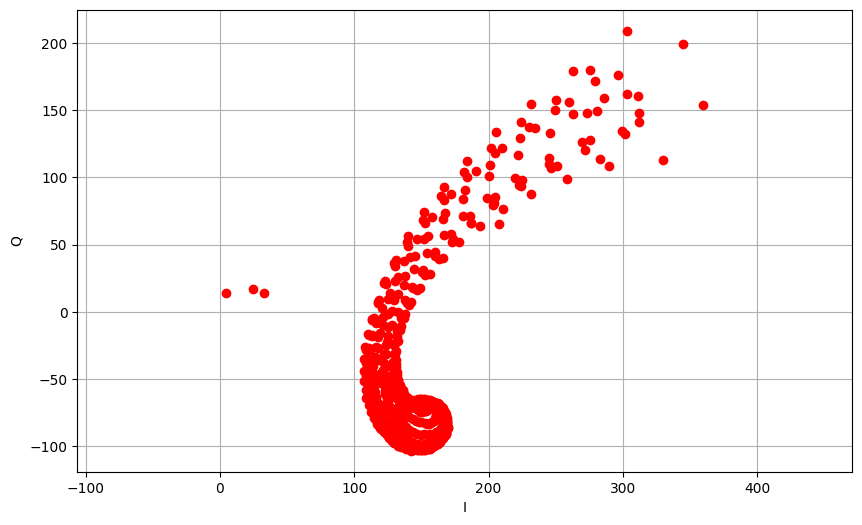

In [113]:
# Split the acquired rows into class-0 and class-1 groups using the matching y labels
acquired_data = np.asarray(acquired_data)
#y_labels = np.asarray(y).reshape(-1)

# if acquired_data.shape[0] != len(y_labels):
#     raise ValueError(f"acquired_data has {acquired_data.shape[0]} rows but y has {len(y_labels)} labels")

X_0 = acquired_data_calibrated[y==0]#_labels == 0]
X_1 = acquired_data_calibrated[y==1]#_labels == 1]

print("rows labeled 0:", X_0.shape[0])
print("rows labeled 1:", X_1.shape[0])

# Split interleaved I/Q pairs as [I0, Q0, I1, Q1, ...]
I_0 = X_0[:, 0::2]
Q_0 = X_0[:, 1::2]
I_1 = X_1[:, 0::2]
Q_1 = X_1[:, 1::2]

mean_I_0_axis = np.mean(I_0, axis=0)
mean_Q_0_axis = np.mean(Q_0, axis=0)
mean_I_1_axis = np.mean(I_1, axis=0)
mean_Q_1_axis = np.mean(Q_1, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

plt.figure(figsize=(10, 6))
plt.plot(mean_I_1_axis, mean_Q_1_axis, 'ro', label='Mean State 1')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

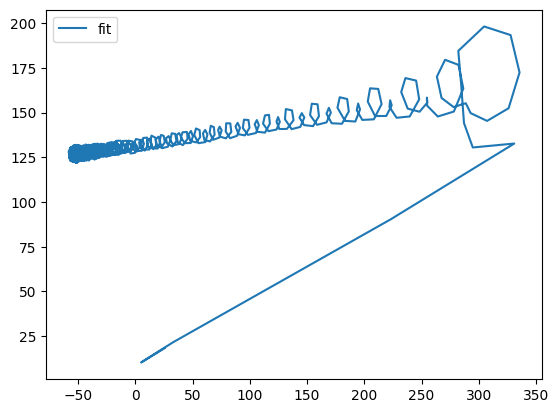

In [114]:
mean_fit0 = np.mean(X_0, axis=0)
mean_fit1 = np.mean(X_1, axis=0)

shots0 = X_0[:,0::2]+1j*X_0[:,1::2]

z0_fit = mean_fit0[0::2] + 1j*mean_fit0[1::2]
z1_fit = mean_fit1[0::2] + 1j*mean_fit1[1::2]

# noise0 = shots0-z0_fit

# print(np.mean(np.abs(noise0)))
# print(np.std(noise0.real))
# print(np.std(noise0.imag))

#plt.plot(z0_fit.real,z0_fit.imag,label="real")
plt.plot(z0_fit.real,z0_fit.imag,label="fit")
plt.legend()


In [115]:
np.save("acquired_data_calibrated.npy", acquired_data_calibrated)

In [116]:
# config["gain"] = 1.0
# config["freq"] = 0
# config["phase"] = 0
# config["outsel"] = "input"

#shot_info = calculate_waveform_vals(dac_waveform)

# config = base_config.copy()
# config.update(shot_info)
# config["waveform"] = dac_waveform

# print(config["waveform"][:20])
# print(np.max(np.abs(config["waveform"])))

#prog = LoopbackProgram(soccfg, config)
# iq = prog.acquire_decimated(soc)
# iq_arr = iq[0]

iq = acquired_data
iq_arr = iq[0]

I = iq_arr[0,:]
Q = iq_arr[1,:]

record = np.empty(2*len(I))

record[0::2] = I
record[1::2] = Q

plt.figure(figsize=(12,4))
plt.plot(I,label="I")
plt.plot(Q,label="Q")
plt.legend()
plt.grid()

iq = record

print(iq[0].shape)
print(iq[0])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
#iq = prog.acquire(soc)

print("type(iq):", type(iq))
if isinstance(iq, list):
    print("iq is a list of arrays, one per readout channel")
    for i, arr in enumerate(iq):
        print(f"channel {i}: shape={getattr(arr, 'shape', None)}")
else:
    print("iq shape:", iq.shape)


In [ ]:
print(type(iq))

for ch, arr in enumerate(iq):
    arr = np.asarray(arr)

    print(f"Channel {ch}")
    print(" shape:", arr.shape)
    print(arr)

In [ ]:
# plot iq
if isinstance(iq, list):
    fig, axes = plt.subplots(len(iq), 1, figsize=(10, 3*len(iq)))
    if len(iq) == 1:
        axes = [axes]
    for ax, arr in zip(axes, iq):
        arr = np.asarray(arr)
        print("channel array shape:", arr.shape)
        if arr.ndim == 1:
            if arr.size >= 2:
                ax.plot([0, 1], arr[:2], marker='o')
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['I', 'Q'])
            else:
                ax.plot(arr, marker='o')
        elif arr.ndim >= 2 and arr.shape[-1] == 2:
            ax.plot(arr[:, 0], label='I')
            ax.plot(arr[:, 1], label='Q')
        else:
            ax.plot(arr.reshape(-1), label='data')
        ax.set_title('Readout channel')
        ax.legend()
else:
    plt.figure(figsize=(10, 6))
    plt.plot(iq)

In [ ]:
np.save(base / 'acquired_iq.npy', iq)

In [ ]:
arr = np.asarray(iq[0])
print(arr.shape)
print(arr[:5])

print("-------------------------------")
arr = np.asarray(iq[0])

print(arr.dtype)
print(arr.shape)
print(arr.min())
print(arr.max())
print(arr[:50])